# **Mission 3: Exploratory Data Analysis (EDA) with the Sales Dataset using Pandas and d Matplotlib/Seaborn**

### **Objective:**

The goal of this assignment is to help you apply your knowledge of Python for basic operations, Pandas for data manipulation, and Matplotlib/Seaborn for visualizations. You'll be working with a real-world dataset, and your tasks will include loading the data, performing EDA, and visualising the results.

###  **Dataset**

The dataset represents transaction data from a retail business, specifically sales data for products sold in various stores. It contains multiple tables that provide insights into sales, invoices, and products. Let’s break down the tables and what they represent:

#### Sales Table:

InvoiceNo: The unique identifier for each invoice (or transaction).

StockCode: A unique identifier for each product.

Quantity: The number of units sold in each transaction.

UnitPrice: The price per unit of the product.

InvoiceDate: The date when the transaction occurred.

#### Invoice Table:

InvoiceNo: The same unique identifier for each invoice, linking the sales data with the invoice details.

Country: The country where the sale was made.

#### Product Table:

StockCode: A unique identifier for each product.

Description: The name or description of the product.

Product_Category: The category the product belongs to (e.g., "Gift", "Sign", "Mug").



You will need to merge them and perform the following tasks step by step.


### Task 1: Load the Excel File
#### Objective: Import the data from the provided Excel file into Python using Pandas.

Instructions:

1. Upload the provided excel file into Fabric environment
2. Read each sheet of the excel file as a separate dataframe. 
3. Name the dataframe for sales as df_sales, the dataframe for invoice as df_invoice and the dataframe for product as df_product
4. Display the first few rows of each DataFrame to understand its structure.



In [16]:
### Code Task Here
import pandas as pd

# Read each sheet in excel file as seperate dataframe and name dataframe for sales as df_sales, dataframe for in voice as df_invoice, dataframe for product as df_product
df_sales = pd.read_excel(f"{notebookutils.nbResPath}/builtin/online_sales_retailer 5.xlsx", sheet_name= "Sales")
df_invoice = pd.read_excel(f"{notebookutils.nbResPath}/builtin/online_sales_retailer 5.xlsx", sheet_name= "Invoice")
df_product = pd.read_excel(f"{notebookutils.nbResPath}/builtin/online_sales_retailer 5.xlsx", sheet_name= "Product")

# Display the first 5 rows of df_sales, df_invoice and df_product
display(df_sales.head(5))
display(df_invoice.head(5))
display(df_product.head(5))

StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 24, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 87a35e41-02d2-4052-9c15-56fa81a7f915)

SynapseWidget(Synapse.DataFrame, a199d86f-18f0-41da-81cf-ebe0a1447b45)

SynapseWidget(Synapse.DataFrame, 491a329b-162e-4a63-9448-f289c84b7160)

### Task 2: Basic Python and Pandas Operations
#### Objective: Perform basic Python and Pandas operations to manipulate the data.

<mark>Instructions:</mark>

1. Check for missing values in the Sales DataFrame.

2. Replace any NaN values in the Sales and UnitPrice columns with 0.

3. Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation).

In [17]:
# Check missing values in df_sales
missing_values = df_sales.isnull()

# Display the rows with null values
rows_with_nulls = df_sales[missing_values.any(axis=1)]
display(rows_with_nulls)

# Create new column named Sales by multiplying "Quantity" and "UnitPrice" and display df_sales to show new column "Sales"
df_sales = df_sales.assign(Sales = df_sales["Quantity"] * df_sales["UnitPrice"])
display(df_sales)

# Replace any NaN values in Sales and UnitPrice columns with 0
df_sales = df_sales.fillna({"Sales": 0, "UnitPrice": 0})

# Calculate the mean, median, mode, standard deviation for "Quantity"
mean_quantity = df_sales["Quantity"].mean()
median_quantity = df_sales["Quantity"].median()
mode_quantity = df_sales["Quantity"].mode()[0]
std_quantity = df_sales["Quantity"].std()

# Calculate the mean, median, mode, standard deviation for "UnitPrice"
mean_unitPrice = df_sales["UnitPrice"].mean()
median_unitPrice = df_sales["UnitPrice"].median()
mode_unitPrice = df_sales["UnitPrice"].mode()[0]
std_unitPrice = df_sales["UnitPrice"].std()

# Display the results of descriptive statistics for "Quantity" and "UnitPrice"
print(f"Quantity - Mean: {mean_quantity}, Median: {median_quantity}, Mode: {mode_quantity}, Std Dev: {std_quantity}")
print(f"UnitPrice - Mean: {mean_unitPrice}, Median: {median_unitPrice}, Mode: {mode_unitPrice}, Std Dev: {std_unitPrice}")

StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 26, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 144d2f56-f877-4569-8afd-f802caff346d)

SynapseWidget(Synapse.DataFrame, f580c9a1-cae6-4380-9355-171cd5c11ba6)

Quantity - Mean: 13.610961009642518, Median: 6.0, Mode: 1, Std Dev: 261.57756533207146
UnitPrice - Mean: 3.0835027678710816, Median: 1.95, Mode: 1.25, Std Dev: 5.177652565375899


### Task 3: Merging DataFrames
#### Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.

Instructions:

1. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.

2. Merge the result with the Product DataFrame on StockCode

In [20]:
# Merge df_sales with df_invoice on InvoiceNo
df_sales_invoice = pd.merge(df_sales, df_invoice, on="InvoiceNo", how="left")

# Merge df_sales_invoice with df_product on StockCode
merged_df = pd.merge(df_sales_invoice, df_product, on="StockCode", how="left")

# Display the merged dataframe merged_df 
display(merged_df)


StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 29, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 3f8de57f-3d48-4769-b7db-6ffc6501db41)

## Task 4: Exploratory Data Analysis (EDA)
### Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.

Instructions:

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

In [21]:
##Importing seaborn matplotlib
!pip install seaborn matplotlib

StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 30, Finished, Available, Finished, False)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate and display summary statistics for numeric columns - "Quantity", "UnitPrice" and "Sales"
described_df = merged_df.loc[:, ["Quantity", "UnitPrice", "Sales"]].describe()
display(described_df)

# Filter out rows where Quantity = 0
filtered_df = merged_df[merged_df["Quantity"] > 0]
display(filtered_df)

StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 31, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 1e928504-a07c-43b2-b3cf-ad80f2b289ac)

SynapseWidget(Synapse.DataFrame, c29a58cd-3e7a-4238-9758-97fc2f0ad0b6)

StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 32, Finished, Available, Finished, False)

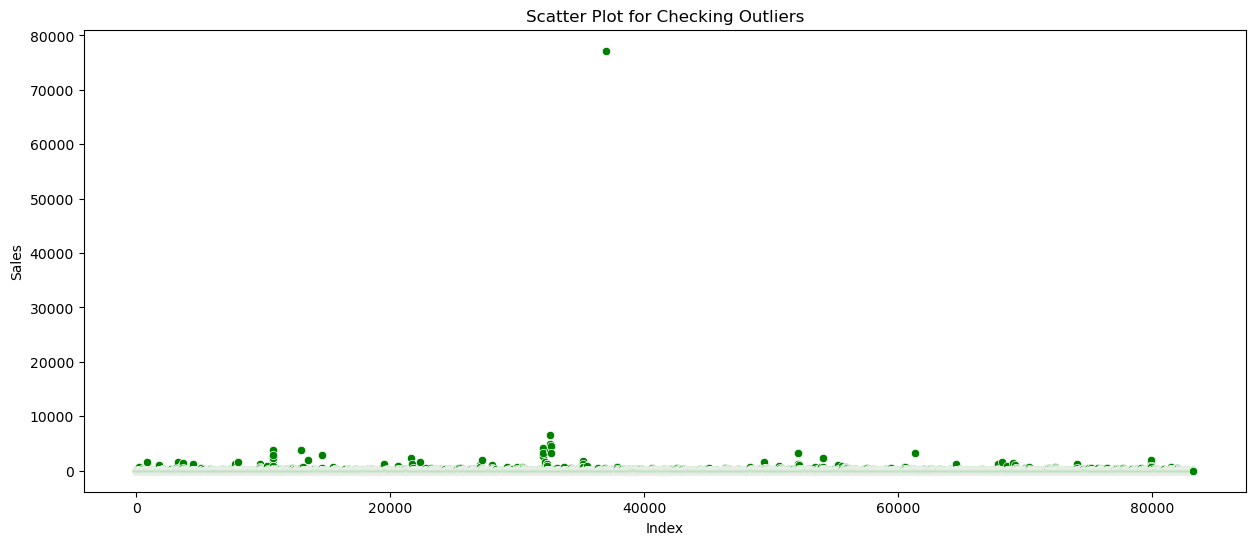

In [23]:
# Check outliers in "Sales" using Scatter plot
plt.figure(figsize=(15, 6))
sns.scatterplot(x=filtered_df.index, y="Sales", data=filtered_df, color="green")
plt.title("Scatter Plot for Checking Outliers")
plt.xlabel("Index")
plt.ylabel("Sales")
plt.show()

#### Note and Explanation

From the Scatter Plot above, most of the data have the sales below 10000, there is only one data has the sales around 80000, which is significantly higher than other data points and falling far outside the normal pattern, therefore the data point with the sales around 80000 is an outlier. 

## Task 5: Data Visualisation – Scatter Plot, Histogram, and Line Chart
### Objective: Create scatter plots, histograms, and line charts to better understand the data.

Instructions:

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.


In [24]:
# Remove the outlier found in task 4 from the dataframe before creating visualisations
cleaned_df = filtered_df[filtered_df["Sales"] < 10000]


StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 34, Finished, Available, Finished, False)

#### Note and Explanation of removing outlier

The reason of removing outliers before creating visualizations is because this can improve visualization clarity, as the outlier found in previous task causes the scatter plot and histogram unreadable, which results difficulty to observe relationship between Quantity and Sales and distribution of Sales.

StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 35, Finished, Available, Finished, False)

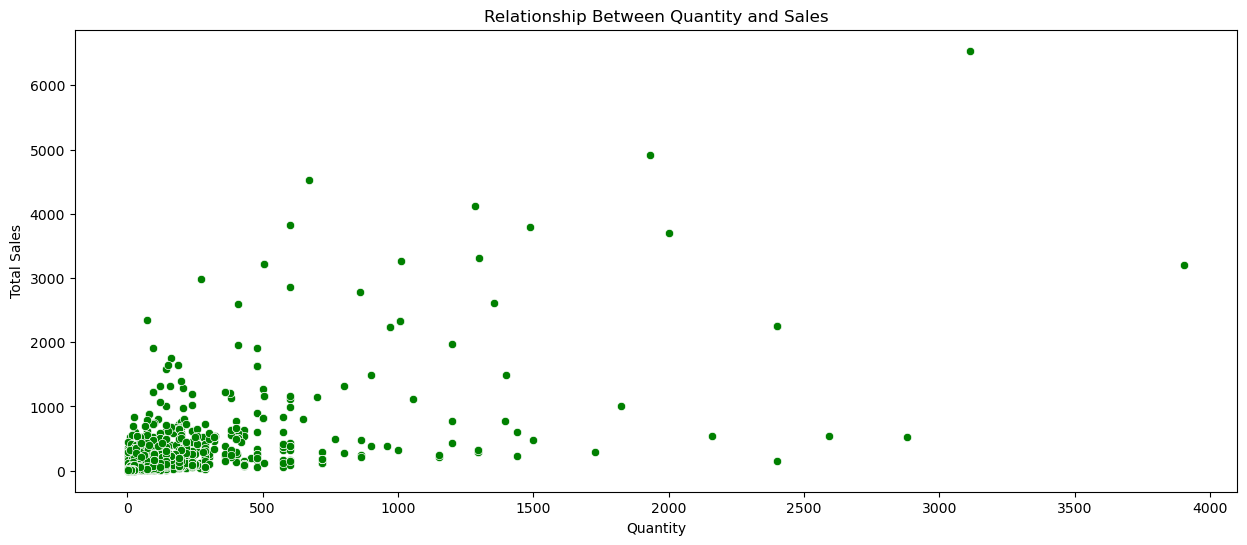

In [25]:
# Create scatter plot to visualise relationship between Quantity and Sales
plt.figure(figsize=(15, 6))
sns.scatterplot(x="Quantity", y="Sales", data=cleaned_df, color="green")
plt.title("Relationship Between Quantity and Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.show()


StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 37, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


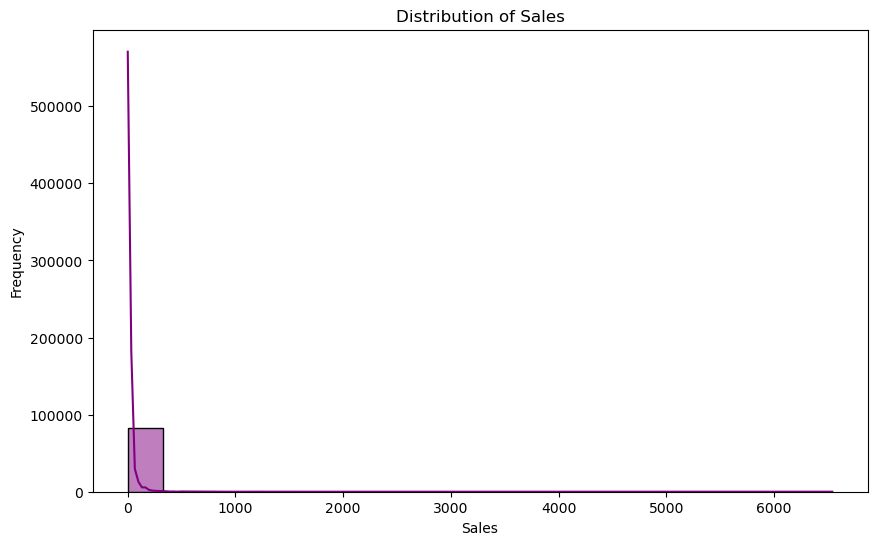

In [26]:
# Create histogram to visualise the distribution of "Sales"
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df["Sales"], bins=20, color="purple", kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.ticklabel_format(style='plain', axis='y') 
plt.show()

StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 39, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


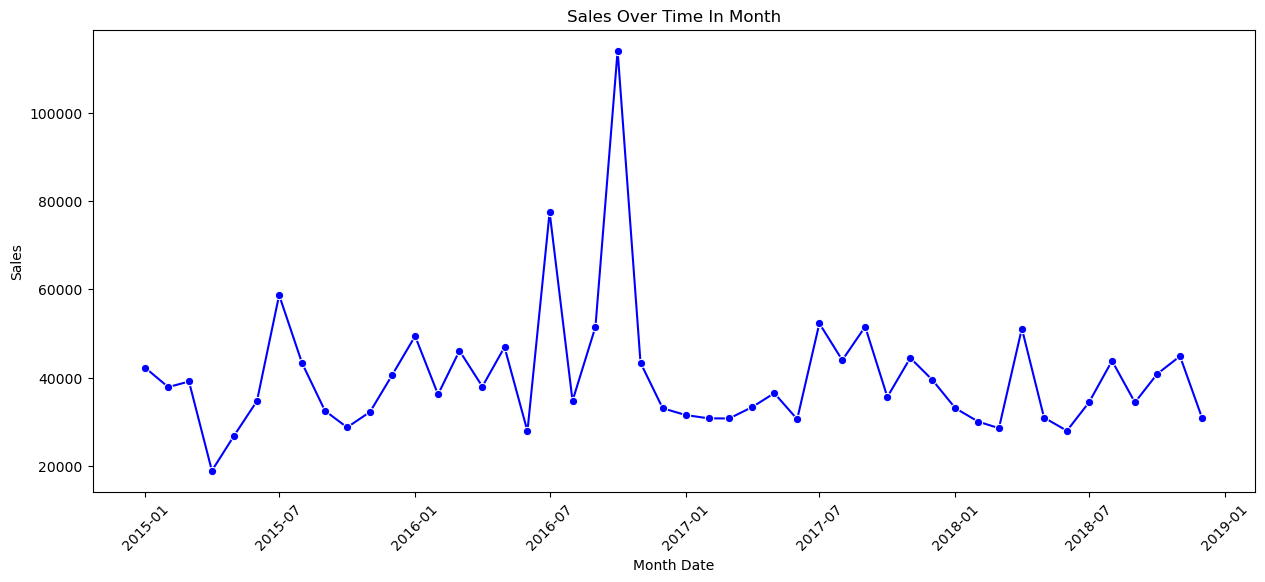

In [27]:
# Convert InvoiceDate to month-year format, then group the sales by month-year to calculate the total sales over time by month
merged_df["Invoice_month_year"] = merged_df["InvoiceDate"].dt.strftime("%m-%Y")
merged_df["Invoice_month_year"] = pd.to_datetime(merged_df["Invoice_month_year"], format="%m-%Y")
sales_over_time = merged_df.groupby("Invoice_month_year")["Sales"].sum().reset_index().sort_values(by="Invoice_month_year")


# Create line chart to visualise Sales over time
plt.figure(figsize=(15, 6))
sns.lineplot(x="Invoice_month_year", y="Sales", data=sales_over_time, marker="o", color="blue")
plt.title("Sales Over Time In Month")
plt.xlabel("Month Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Task 6: Correlation and Data Insights
### Objective: Identify the relationship between different numerical columns in the dataset.

Instructions:

Calculate the correlation between Quantity and Sales.

Visualise the correlation matrix using a heatmap.

StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 41, Finished, Available, Finished, False)

          Quantity     Sales
Quantity  1.000000  0.978609
Sales     0.978609  1.000000


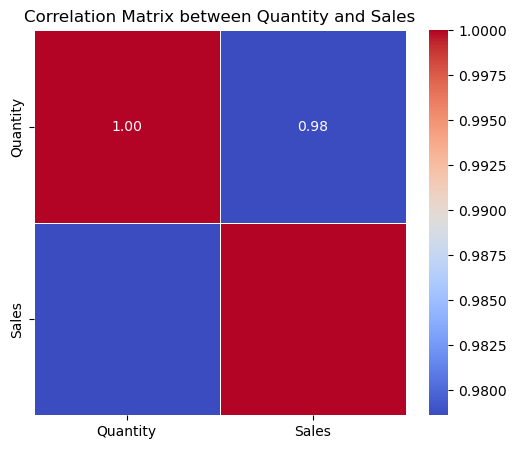

In [28]:
# Calculate correlation between "Quantity" and "Sales", then display the correlation matrix
correlation = merged_df[["Quantity", "Sales"]].corr()
print(correlation)

# Create heatmap for the correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix between Quantity and Sales")
plt.show()

## Task 7: Grouping and Aggregating
### Objective: Perform grouping and aggregation operations to summarise the data.

Instructions:

GroupBy operation: Group by Product_Category and calculate the total Sales per category.

Create a Pivot Table to show Sales by Country and Product_Category.

In [29]:
# Group by Product_Category and calculate total sales per category in descending order
sales_by_category = merged_df.groupby("Product_Category")["Sales"].sum().reset_index()
sales_by_category = sales_by_category.sort_values(by="Sales", ascending=False)

# Display total sales per category
display(sales_by_category)

# Create Pivot table for Sales by Country and Product_Category, and reset index to make "Product_Category" as normal column
pivot_table = merged_df.pivot_table(values="Sales", index="Product_Category", columns="Country", aggfunc="sum").reset_index()

# Display the pivot table
display(pivot_table)

StatementMeta(, 10d7e2fb-0218-47ca-bda0-d7722c9c57e1, 43, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, e849344b-39b8-4c50-a8f4-d7a395904a81)

SynapseWidget(Synapse.DataFrame, a5f40987-8c13-4403-acbf-4d14bc5cd353)

## Submission Guidelines:
Submit the Python notebook with all the tasks and visualisations.

Ensure that each task is clearly explained and that all steps are followed.

Include markdown explanations where necessary to explain your thought process.

Well done on the code and on provide explanations of you approach, however it is also important to provide insights after the outputs from the code. Jose